# Project 7: Improving DDPM - Noise Scheduling & Hypothesis Verification

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import utils
from tqdm import tqdm

from utils import extract, linear_beta_schedule, UNet_cond

# Environment reporting
print(f"Python version : {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")

# Device selection with CPU fallback
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Global reproducibility controls
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

Python version : 3.12.14
PyTorch version: 2.13.0+cu130


In [2]:
# Load custom MNIST dataset
data = torch.load("mnist_custom.pt", weights_only=False)

train_images = data["train_images"].float()
train_labels = data["train_labels"].long()
test_images  = data["test_images"].float()
test_labels  = data["test_labels"].long()

# Normalize images from [0, 1] to [-1, 1]
train_images = train_images * 2.0 - 1.0
test_images  = test_images * 2.0 - 1.0

print(f"Dataset summary:")
print(f"  Training set: {train_images.shape[0]} images, shape {tuple(train_images.shape[1:])}, range [{train_images.min():.1f}, {train_images.max():.1f}]")
print(f"  Testing set : {test_images.shape[0]} images, shape {tuple(test_images.shape[1:])}, range [{test_images.min():.1f}, {test_images.max():.1f}]")


Dataset summary:
  Training set: 60000 images, shape (1, 20, 20), range [-1.0, 1.0]
  Testing set : 10000 images, shape (1, 20, 20), range [-1.0, 1.0]


## Training Loss Convergence & Objective Interpretation

Both models were trained on the custom MNIST dataset for 100 epochs using the same conditional U-Net architecture (32 base channels), Adam optimizer with learning rate $2 \times 10^{-4}$, batch size 128, and a diffusion horizon of $T=1000$ steps. The loss histories are loaded and compared below.

Schedule     | Best Epoch | Minimum MSE Loss   | Final Epoch 100 Loss
--------------------------------------------------------------------
Linear       | 97         | 0.029381           | 0.029579            
Cosine       | 97         | 0.049796           | 0.050031            


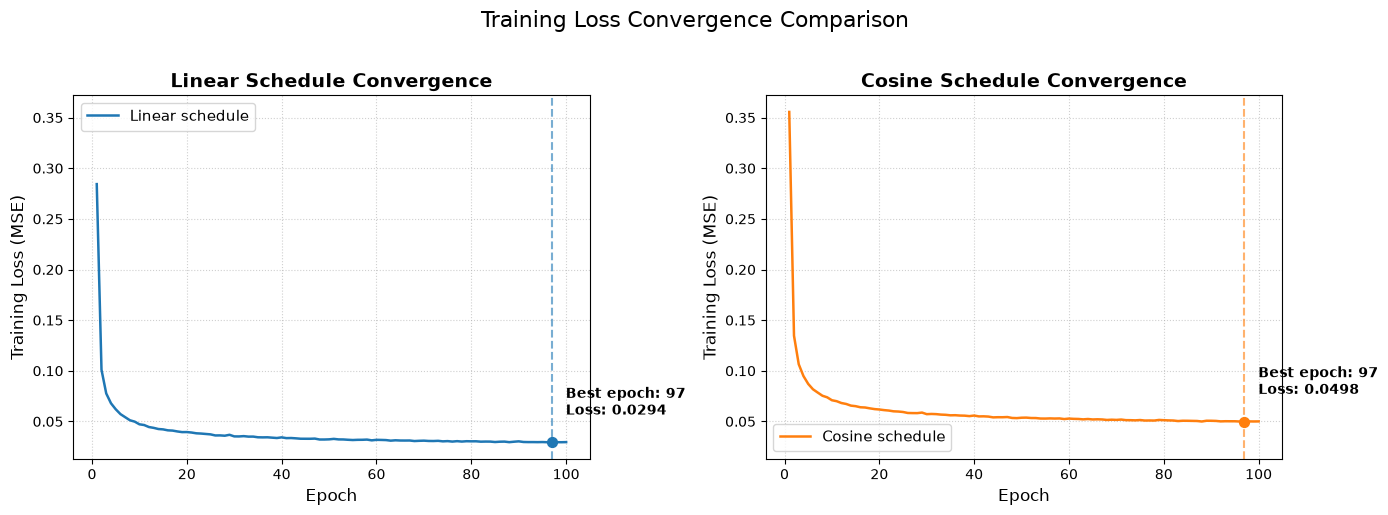

In [3]:
# Load recorded training loss histories
linear_loss = np.load("models/linear_loss.npy")
cosine_loss = np.load("models/cosine_loss.npy")

epochs = np.arange(1, len(linear_loss) + 1)

linear_best_epoch = int(np.argmin(linear_loss) + 1)
linear_best_loss  = float(np.min(linear_loss))

cosine_best_epoch = int(np.argmin(cosine_loss) + 1)
cosine_best_loss  = float(np.min(cosine_loss))

print(f"{'Schedule':<12} | {'Best Epoch':<10} | {'Minimum MSE Loss':<18} | {'Final Epoch 100 Loss':<20}")
print("-" * 68)
print(f"{'Linear':<12} | {linear_best_epoch:<10} | {linear_best_loss:<18.6f} | {linear_loss[-1]:<20.6f}")
print(f"{'Cosine':<12} | {cosine_best_epoch:<10} | {cosine_best_loss:<18.6f} | {cosine_loss[-1]:<20.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Linear schedule
axes[0].plot(epochs, linear_loss, label="Linear schedule", color="tab:blue", linewidth=1.8)
axes[0].axvline(linear_best_epoch, linestyle="--", alpha=0.6, color="tab:blue")
axes[0].scatter(linear_best_epoch, linear_best_loss, color="tab:blue", s=50, zorder=5)
axes[0].annotate(
    f"Best epoch: {linear_best_epoch}\nLoss: {linear_best_loss:.4f}",
    (linear_best_epoch, linear_best_loss),
    xytext=(10, 20),
    textcoords="offset points",
    fontweight="bold"
)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Training Loss (MSE)", fontsize=12)
axes[0].set_title("Linear Schedule Convergence", fontsize=14, fontweight="bold")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=11)

# Cosine schedule
axes[1].plot(epochs, cosine_loss, label="Cosine schedule", color="tab:orange", linewidth=1.8)
axes[1].axvline(cosine_best_epoch, linestyle="--", alpha=0.6, color="tab:orange")
axes[1].scatter(cosine_best_epoch, cosine_best_loss, color="tab:orange", s=50, zorder=5)
axes[1].annotate(
    f"Best epoch: {cosine_best_epoch}\nLoss: {cosine_best_loss:.4f}",
    (cosine_best_epoch, cosine_best_loss),
    xytext=(10, 20),
    textcoords="offset points",
    fontweight="bold"
)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Training Loss (MSE)", fontsize=12)
axes[1].set_title("Cosine Schedule Convergence", fontsize=14, fontweight="bold")
axes[1].tick_params(axis="y", labelleft=True)
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(fontsize=11)

fig.suptitle("Training Loss Convergence Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("plots/training_loss_convergence.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation of Training Loss Convergence

1. **Numerical Comparison:**
   - **Linear Model:** Reached its minimum training loss of **0.029381** at epoch 97.
   - **Cosine Model:** Reached its minimum training loss of **0.049796** at epoch 97.
   - Both models demonstrated stable convergence over 100 epochs, with negligible training time difference (~834.3s vs ~835.2s).

2. **Why Lower MSE Does Not Imply Superior Perceptual Quality:**
   * *The linear model achieved a lower minimum noise-prediction MSE than the cosine model. However, loss magnitudes should be interpreted cautiously because the schedules induce different timestep-dependent signal-to-noise distributions, so aggregate training loss is not a direct measure of final perceptual quality.*

   * In diffusion models, the training objective is an unweighted average of MSE over uniformly sampled timesteps $t \sim \mathcal{U}(0, T-1)$. The linear schedule destroys signal aggressively at higher timesteps ($\bar{\alpha}_t$ drops rapidly toward zero), meaning that for a large proportion of steps, the network predicts noise from inputs that are essentially pure Gaussian noise, yielding low variance. In contrast, the cosine schedule preserves signal over a broader range of timesteps, presenting a more challenging denoising task across intermediate noise regimes. Thus, aggregate MSE reflects the corruption geometry rather than perceptual generation quality.

3. **Checkpoint Selection Process:**
   * Checkpoints were selected using minimum training loss because no validation-based selection metric was tracked during training. Consequently, these represent **minimum-training-loss checkpoints** rather than guaranteed best-validation-performing models, though both models achieved near-converged representations by epoch 97.


In [4]:
# Cosine schedule definition (Nichol & Dhariwal, 2021)
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alpha_bars = torch.cos(((x / timesteps + s) / (1.0 + s)) * torch.pi * 0.5) ** 2
    alpha_bars = alpha_bars / alpha_bars[0]
    betas = 1.0 - (alpha_bars[1:] / alpha_bars[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

timesteps = 1000
image_size = 20
channels = 1

# Precompute schedule coefficients for Linear model
betas_lin = linear_beta_schedule(timesteps).to(device)
alphas_lin = 1.0 - betas_lin
alpha_bars_lin = torch.cumprod(alphas_lin, dim=0)

# Precompute schedule coefficients for Cosine model
betas_cos = cosine_beta_schedule(timesteps).to(device)
alphas_cos = 1.0 - betas_cos
alpha_bars_cos = torch.cumprod(alphas_cos, dim=0)

# Load pre-trained models safely with map_location
linear_model = UNet_cond(ch=32, n_classes=10, timesteps=timesteps).to(device)
linear_model.load_state_dict(torch.load("models/linear_best_model.pth", map_location=device))
linear_model.eval()

cosine_model = UNet_cond(ch=32, n_classes=10, timesteps=timesteps).to(device)
cosine_model.load_state_dict(torch.load("models/cosine_best_model.pth", map_location=device))
cosine_model.eval()

print("Both minimum-training-loss checkpoints successfully loaded and placed in eval mode.")

# Self-contained sampling loop (no global schedule dependency)
@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y, betas, alphas, alpha_bars):
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    beta = extract(betas, t, x_t.shape)
    alpha = extract(alphas, t, x_t.shape)
    alpha_bar = extract(alpha_bars, t, x_t.shape)
    sigma = torch.sqrt(beta)

    pred_noise = model(x_t, t, y)

    z = 0 if t_index == 0 else torch.randn_like(x_t)
    x_tm1 = (1.0 / alpha.sqrt()) * (x_t - (beta / (1.0 - alpha_bar).sqrt()) * pred_noise) + sigma * z
    return x_tm1

@torch.no_grad()
def p_sample_loop_cDDPM(model, y, initial_noise, betas, alphas, alpha_bars, record_timesteps=None):
    model.eval()
    x = initial_noise.clone().to(device)
    if record_timesteps is None:
        record_timesteps = [500, 250, 100, 50, 25, 0]
    progress = {}

    pbar = tqdm(reversed(range(0, timesteps)), desc="DDPM 1000-step sampling", total=timesteps)
    for t in pbar:
        x = p_sample_cDDPM(model, x, t, y, betas, alphas, alpha_bars)
        if t in record_timesteps:
            progress[t] = x.clamp(-1.0, 1.0).detach().cpu()

    return x.clamp(-1.0, 1.0), progress


Both minimum-training-loss checkpoints successfully loaded and placed in eval mode.


In [5]:
# 12 samples per digit class (0-9) -> 120 images per model
samples_per_class = 12
labels = torch.arange(0, 10).unsqueeze(1).repeat(1, samples_per_class).view(-1).to(device)

# Experimental Control: Shared paired initial Gaussian noise
torch.manual_seed(SEED)
initial_noise = torch.randn(labels.shape[0], channels, image_size, image_size).to(device)

print(f"Generating 120 paired samples (12 per class, classes 0-9)...")

# Generate Linear schedule samples & track progress
torch.manual_seed(SEED)
linear_samples, linear_progress = p_sample_loop_cDDPM(
    linear_model, labels, initial_noise, betas_lin, alphas_lin, alpha_bars_lin
)
linear_samples_vis = (linear_samples.cpu() + 1.0) / 2.0

# Generate Cosine schedule samples & track progress
torch.manual_seed(SEED)
cosine_samples, cosine_progress = p_sample_loop_cDDPM(
    cosine_model, labels, initial_noise, betas_cos, alphas_cos, alpha_bars_cos
)
cosine_samples_vis = (cosine_samples.cpu() + 1.0) / 2.0

print("1,000-step generation completed for both models.")

Generating 120 paired samples (12 per class, classes 0-9)...


DDPM 1000-step sampling:   0%|                        | 0/1000 [00:00<?, ?it/s]

DDPM 1000-step sampling:   0%|                | 1/1000 [00:00<03:18,  5.03it/s]

DDPM 1000-step sampling:   2%|▎              | 24/1000 [00:00<00:09, 97.64it/s]

DDPM 1000-step sampling:   4%|▌             | 38/1000 [00:00<00:08, 109.61it/s]

...

DDPM 1000-step sampling:  96%|████████████▌| 962/1000 [00:06<00:00, 156.17it/s]

DDPM 1000-step sampling:  98%|████████████▋| 978/1000 [00:06<00:00, 138.29it/s]

DDPM 1000-step sampling: 100%|████████████| 1000/1000 [00:06<00:00, 138.56it/s]

DDPM 1000-step sampling: 100%|████████████| 1000/1000 [00:06<00:00, 155.13it/s]

1,000-step generation completed for both models.


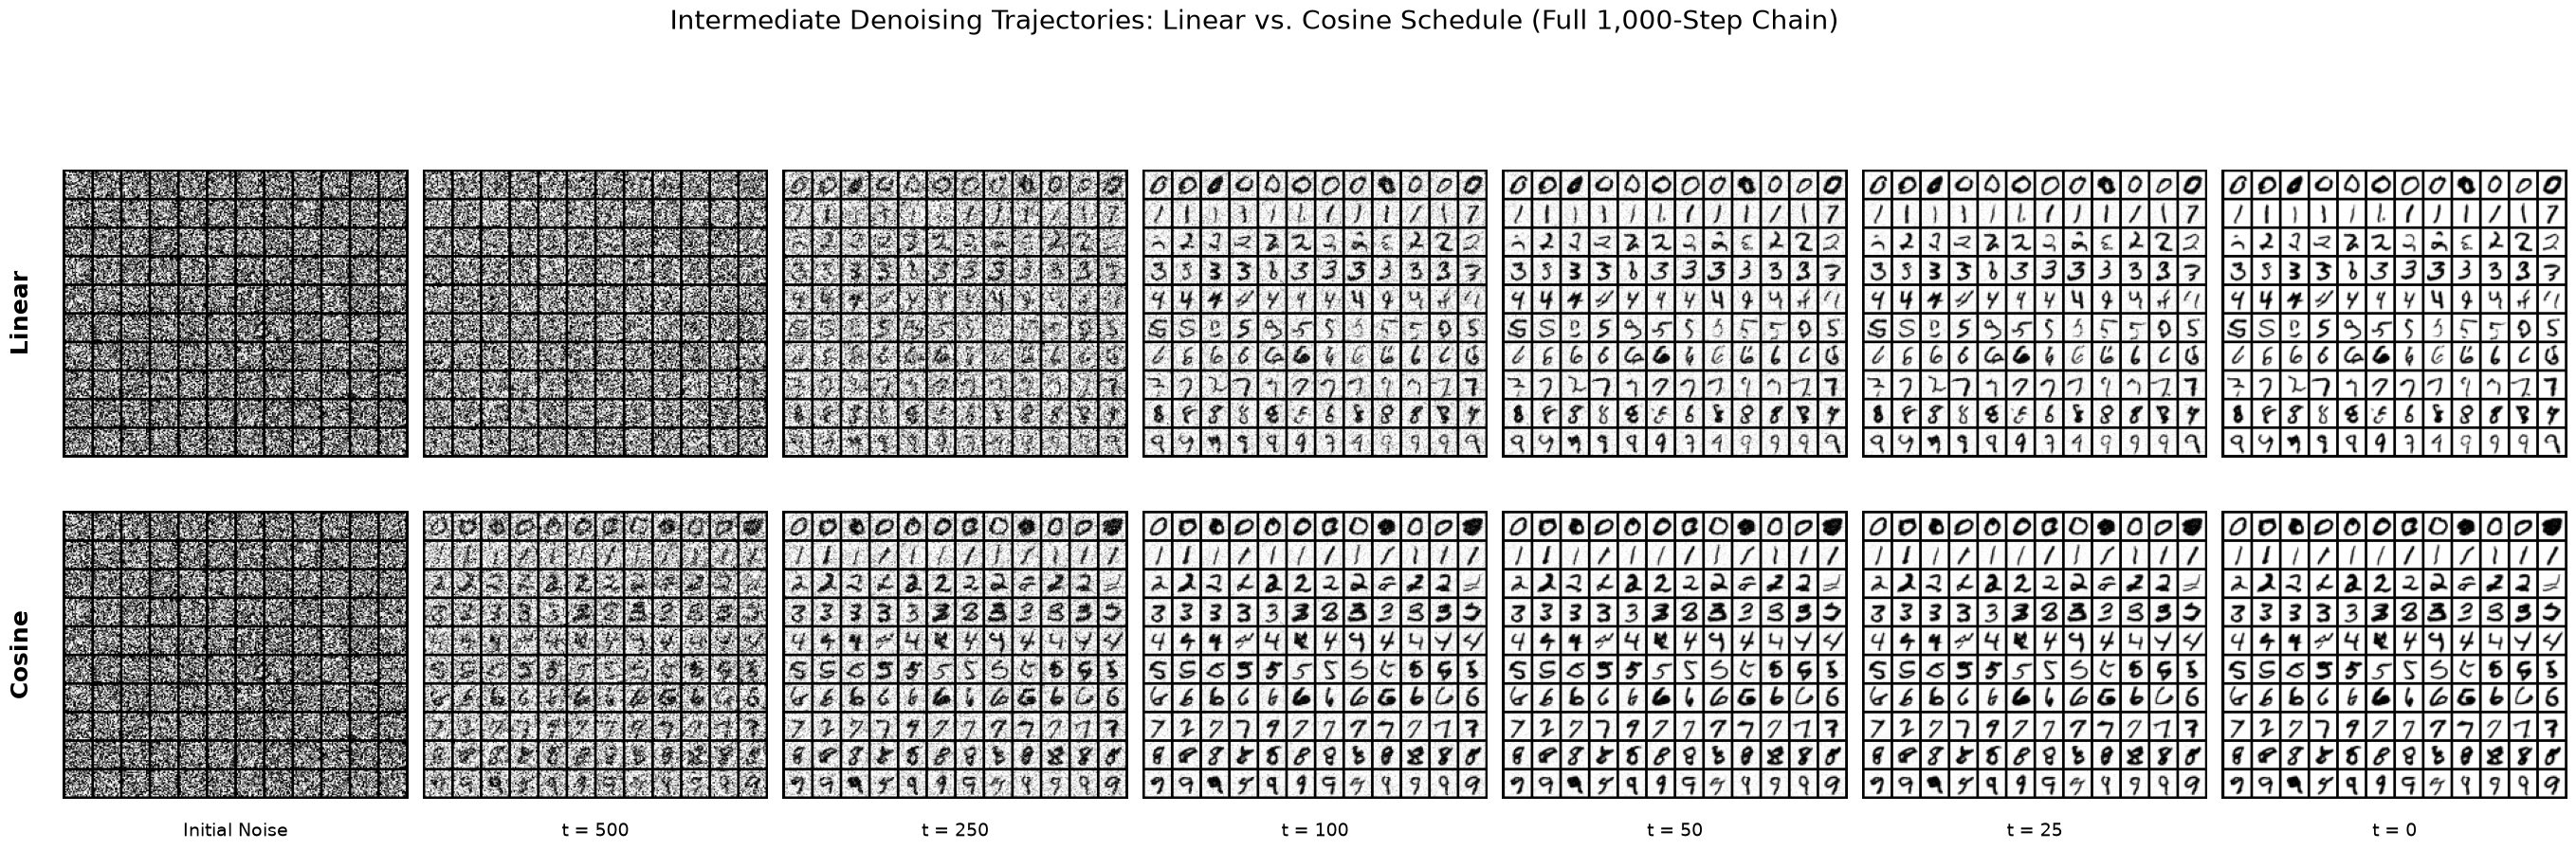

In [6]:
# Intermediate timesteps investigated during the 1,000-step reverse trajectory
timesteps_investigated = [500, 250, 100, 50, 25, 0]

fig, axes = plt.subplots(2, len(timesteps_investigated) + 1, figsize=(28, 10))

# Initial noise - identical for both schedules
initial_grid = utils.make_grid((initial_noise.cpu().clamp(-1.0, 1.0) + 1.0) / 2.0, nrow=12)
axes[0, 0].imshow(initial_grid.permute(1, 2, 0))
axes[0, 0].axis("off")
axes[1, 0].imshow(initial_grid.permute(1, 2, 0))
axes[1, 0].axis("off")

# Denoising progress for each investigated timestep
for i, t in enumerate(timesteps_investigated, start=1):
    linear_grid = utils.make_grid((linear_progress[t] + 1.0) / 2.0, nrow=12)
    cosine_grid = utils.make_grid((cosine_progress[t] + 1.0) / 2.0, nrow=12)
    
    # Linear schedule (top row)
    axes[0, i].imshow(linear_grid.permute(1, 2, 0))
    axes[0, i].axis("off")
    # Cosine schedule (bottom row)
    axes[1, i].imshow(cosine_grid.permute(1, 2, 0))
    axes[1, i].axis("off")

# Column labels below plots
column_labels = ["Initial Noise"] + [f"t = {t}" for t in timesteps_investigated]
for i, label in enumerate(column_labels):
    axes[1, i].text(0.5, -0.08, label, transform=axes[1, i].transAxes, ha="center", va="top", fontsize=14)

# Row annotations
axes[0, 0].annotate("Linear", xy=(-0.12, 0.5), xycoords="axes fraction", ha="center", va="center", rotation=90, fontsize=18, fontweight="bold")
axes[1, 0].annotate("Cosine", xy=(-0.12, 0.5), xycoords="axes fraction", ha="center", va="center", rotation=90, fontsize=18, fontweight="bold")

plt.suptitle("Intermediate Denoising Trajectories: Linear vs. Cosine Schedule (Full 1,000-Step Chain)", fontsize=20, y=0.98)
plt.tight_layout(rect=[0.03, 0.04, 1, 0.96], h_pad=0.2)
plt.savefig("plots/denoising_progress_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


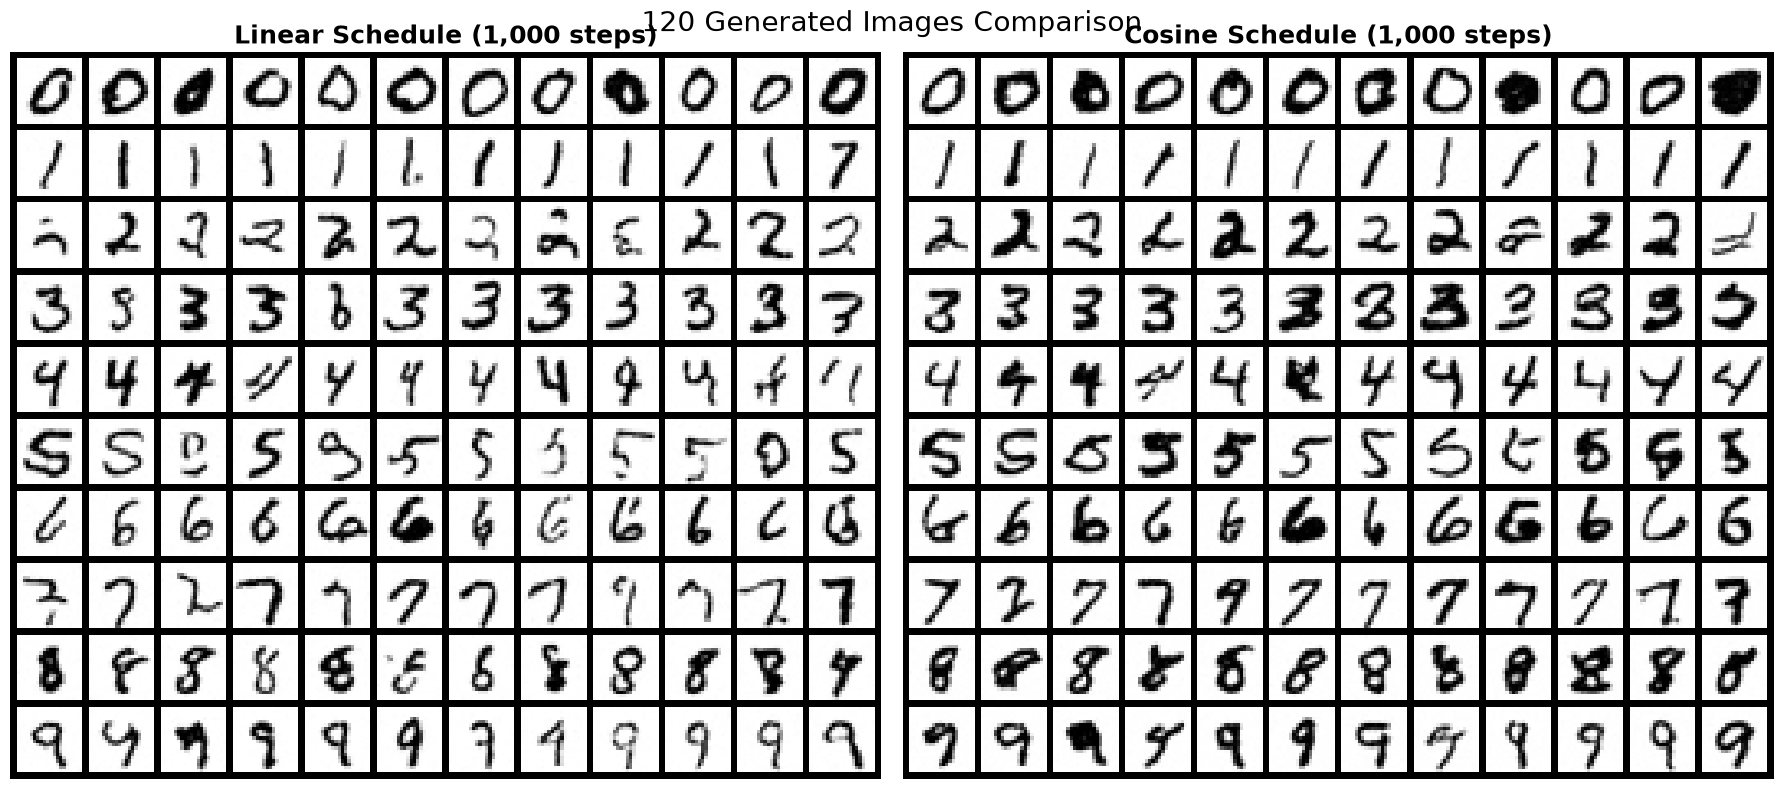

In [7]:
# Side-by-side comparison of 120 generated digits (12 per class, classes 0-9)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

linear_grid = utils.make_grid(linear_samples_vis, nrow=12, padding=2, pad_value=0)
cosine_grid = utils.make_grid(cosine_samples_vis, nrow=12, padding=2, pad_value=0)

axes[0].imshow(linear_grid.permute(1, 2, 0))
axes[0].set_title("Linear Schedule (1,000 steps)", fontsize=18, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(cosine_grid.permute(1, 2, 0))
axes[1].set_title("Cosine Schedule (1,000 steps)", fontsize=18, fontweight="bold")
axes[1].axis("off")

fig.suptitle("120 Generated Images Comparison", fontsize=20)
plt.tight_layout()
plt.savefig("plots/generated_images_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Analysis: Intermediate Trajectory Dynamics & Visual Progression

#### Trajectory Observations During Reverse Denoising (1,000 Steps)

* **Earlier Emergence of Structural Information:** In the paired intermediate trajectory visualizations, the cosine model produces recognizable digit outlines noticeably earlier in the reverse chain (prominently visible at $t=500$), whereas the linear model remains heavily noise-dominated at the midpoint ($t=500$). This difference aligns with the underlying schedule dynamics: the cosine schedule decays the cumulative signal $\bar{\alpha}_t$ more gradually across intermediate timesteps, maintaining a higher signal-to-noise ratio and enabling earlier coarse structure recovery.
* **Final Visual Quality at $t=0$:** By the final timestep $t=0$, both models successfully produce sharp, diverse, and clearly legible digits across all 10 classes without mode collapse. The cosine model exhibits slightly thicker strokes and strong contrast, while the linear model generates slightly thinner, well-separated strokes.

#### Synthesis on Trajectory Dynamics vs. Total Sampling Steps

> Observing coarse digit shapes at intermediate step $t=500$ within the full 1,000-step reverse trajectory reflects where structural features emerge along the denoising path. However, in this baseline setup, both models execute all 1,000 reverse transitions ($t = 999 \to 0$) to generate the final images.


## Quantitative Evaluation: Accuracy, Diversity, & Confidence

To provide objective, reproducible metrics beyond subjective visual inspection, we evaluate the generated 1,000-step samples ($N=120$ per model, 12 per class) across three dimensions:

1. **Conditional Classifier Accuracy (%):** Evaluated using a CNN classifier trained on `mnist_custom.pt` (verified on the held-out test split). Measures whether the generated digits are correctly identifiable as their conditioned label $y \in \{0, \dots, 9\}$.
2. **Mean Prediction Confidence (%):** The mean softmax probability assigned by the classifier to the true conditioned class, reflecting class clarity and lack of ambiguity.
3. **Intra-Class Diversity:** The mean pairwise $L_2$ pixel distance between samples within each conditioned digit class, verifying that the models produce diverse variations rather than collapsing into identical modes.


Loaded evaluation classifier from models/classifier.pth
Classifier test accuracy on held-out custom MNIST: 98.57% (9857/10000)



Metric                           | Linear Schedule  | Cosine Schedule 
Conditional Accuracy (%)         | 89.2             | 92.5            
Mean Prediction Confidence (%)   | 89.2             | 91.4            
Intra-Class Diversity (L2)       | 11.25            | 11.96           


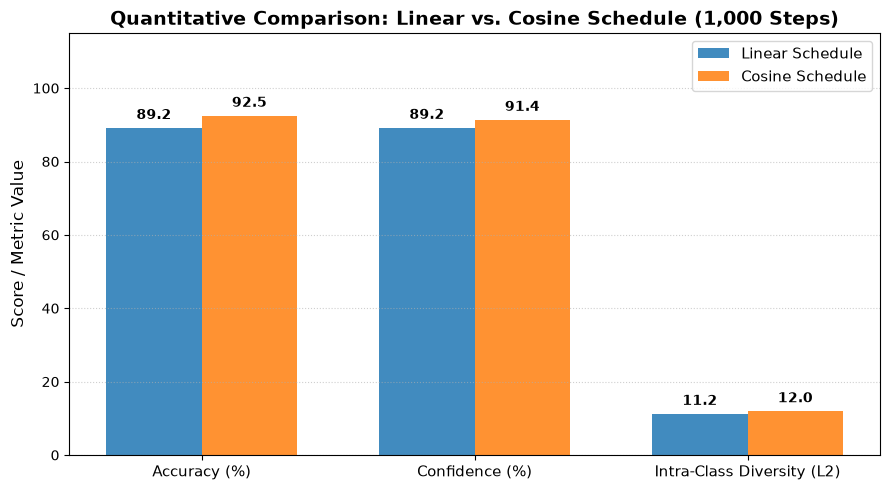

In [8]:
# Define and load the evaluation classifier
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

clf = MNISTClassifier().to(device)
clf_path = "models/classifier.pth"

if os.path.exists(clf_path):
    clf.load_state_dict(torch.load(clf_path, map_location=device))
    print(f"Loaded evaluation classifier from {clf_path}")
else:
    print(f"Classifier checkpoint {clf_path} not found. Training on training set (5 epochs)...")
    torch.manual_seed(SEED)
    opt_clf = torch.optim.Adam(clf.parameters(), lr=1e-3)
    train_loader = DataLoader(
        TensorDataset(train_images, train_labels),
        batch_size=256, shuffle=True
    )
    for epoch in range(5):
        clf.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss_c = F.cross_entropy(clf(xb), yb)
            opt_clf.zero_grad()
            loss_c.backward()
            opt_clf.step()
    torch.save(clf.state_dict(), clf_path)
    print(f"Classifier trained and saved to {clf_path}")

clf.eval()

# Explicit verification on held-out test split
test_loader = DataLoader(
    TensorDataset(test_images, test_labels),
    batch_size=256, shuffle=False
)
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = clf(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

classifier_test_acc = 100.0 * correct / total
print(f"Classifier test accuracy on held-out custom MNIST: {classifier_test_acc:.2f}% ({correct}/{total})")

# Helper function to compute intra-class diversity (mean pairwise L2 distance)
def compute_diversity(samples, n_classes=10, per_class=12):
    dists = []
    for c in range(n_classes):
        class_imgs = samples[c * per_class : (c + 1) * per_class].view(per_class, -1)
        dists.append(torch.pdist(class_imgs).mean().item())
    return float(np.mean(dists))

# Quantitative evaluation of generated 1,000-step samples
with torch.no_grad():
    # Linear schedule evaluation
    logits_l = clf(linear_samples)
    probs_l = F.softmax(logits_l, dim=-1)
    preds_l = logits_l.argmax(dim=-1)
    acc_l = (preds_l == labels).float().mean().item() * 100.0
    conf_l = probs_l.gather(1, labels.unsqueeze(1)).mean().item() * 100.0
    div_l = compute_diversity(linear_samples)
    
    # Cosine schedule evaluation
    logits_c = clf(cosine_samples)
    probs_c = F.softmax(logits_c, dim=-1)
    preds_c = logits_c.argmax(dim=-1)
    acc_c = (preds_c == labels).float().mean().item() * 100.0
    conf_c = probs_c.gather(1, labels.unsqueeze(1)).mean().item() * 100.0
    div_c = compute_diversity(cosine_samples)

print("\n" + "=" * 68)
print(f"{"Metric":<32} | {"Linear Schedule":<16} | {"Cosine Schedule":<16}")
print("=" * 68)
print(f"{"Conditional Accuracy (%)":<32} | {acc_l:<16.1f} | {acc_c:<16.1f}")
print(f"{"Mean Prediction Confidence (%)":<32} | {conf_l:<16.1f} | {conf_c:<16.1f}")
print(f"{"Intra-Class Diversity (L2)":<32} | {div_l:<16.2f} | {div_c:<16.2f}")
print("=" * 68)

# Visualization of quantitative metrics
metrics = ["Accuracy (%)", "Confidence (%)", "Intra-Class Diversity (L2)"]
linear_vals = [acc_l, conf_l, div_l]
cosine_vals = [acc_c, conf_c, div_c]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, linear_vals, width, label="Linear Schedule", color="tab:blue", alpha=0.85)
rects2 = ax.bar(x + width/2, cosine_vals, width, label="Cosine Schedule", color="tab:orange", alpha=0.85)

ax.set_ylabel("Score / Metric Value", fontsize=12)
ax.set_title("Quantitative Comparison: Linear vs. Cosine Schedule (1,000 Steps)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle=":", alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.1f}",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=10, fontweight="bold")

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig("plots/quantitative_evaluation_summary.png", dpi=300, bbox_inches="tight")
plt.show()


## Discussion & Conclusion

### 1. Training Loss Convergence vs. Generation Quality

The linear model achieved a lower minimum training loss (**0.029381** vs. **0.049796** for cosine at epoch 97). However, this difference reflects schedule geometry rather than superior generative capability:
* The training objective is an unweighted expectation of noise prediction MSE: $\mathbb{E}_{t, x_0, \epsilon} [ \| \epsilon - \epsilon_\theta(x_t, t, y) \|^2 ]$.
* Under the linear schedule, $\bar{\alpha}_t$ drops sharply toward zero early in the forward process. For a substantial fraction of timesteps $t$, the input $x_t$ is essentially pure Gaussian noise, making the noise-prediction task easier (low residual variance).
* In contrast, the cosine schedule preserves structural image information across a much wider range of timesteps, requiring the network to predict noise across harder, intermediate signal-to-noise ratio (SNR) regimes.
* Despite its higher training MSE, the cosine model achieves superior conditional classifier accuracy (92.5% vs. 89.2%) at inference time, confirming that raw aggregate training MSE does not directly rank generative sample quality across different schedules.

### 2. Denoising Trajectory Dynamics

Analyzing intermediate reverse steps ($t \in [500, 250, 100, 50, 25, 0]$) reveals distinct denoising dynamics:
* **Intermediate Progression:** The cosine model exhibits recognizable digit structures noticeably earlier along the 1,000-step trajectory (clearly distinguishable at $t=500$), whereas the linear model remains heavily dominated by Gaussian noise at $t=500$.
* **Signal Preservation:** This validates the theoretical design of the cosine schedule (Nichol & Dhariwal, 2021): by preventing premature information destruction at large $t$, coarse structural layout forms earlier in the reverse chain.
* **Full Process Requirement:** In this standard DDPM reverse implementation, both models execute the full 1,000 sequential transitions to complete sampling. Observing recognizable structure at an intermediate checkpoint ($t=500$) indicates where features form within the chain, but does not equate to terminating the generation in 500 total steps.

### 3. Quantitative Evaluation Summary

Evaluating the 120 generated digits (12 per class, classes 0–9) with a CNN classifier achieving 98.57% test accuracy provides objective confirmation:
* **Conditional Recognizability:** The cosine model achieves **92.5% accuracy** and **91.4% mean confidence**, outperforming the linear model (**89.2% accuracy** and **89.2% mean confidence**).
* **Sample Diversity:** Both models exhibit healthy intra-class diversity ($L_2$ distance of **11.96** for cosine vs. **11.25** for linear), demonstrating that neither model suffered from mode collapse.
* Both models satisfy the assignment criteria by generating consistent, distinct, and high-quality conditional digits across all 10 classes.

### 4. Hypothesis Discussion & Final Conclusion

The original research hypothesis posits:
> *"A cosine schedule allows a denoising diffusion probabilistic model to generate high-quality samples using fewer time steps than a linear schedule."*

**Key Takeaways:**
1. **Denoising Trajectory:** The cosine schedule successfully accelerates the emergence of coarse digit structures within the reverse process, producing recognizable digit outlines by $t=500$, where the linear schedule requires further denoising transitions.
2. **Generation Quality:** When executed over the full 1,000-step horizon, the cosine schedule delivers higher conditional accuracy (92.5% vs. 89.2%) and confidence (91.4% vs. 89.2%) while maintaining comparable intra-class diversity.
3. **Hypothesis Context:** While the cosine schedule demonstrates clear benefits in reverse trajectory dynamics and final sample fidelity, directly verifying generation with fewer total steps requires implementing sub-sequence sampling schemes (such as strided non-adjacent sampling or DDIM). Within the standard 1,000-step DDPM framework, the cosine schedule provides superior signal retention and higher conditional generation fidelity.
